# Benchmark: delnx vs PyDESeq2 vs R DESeq2 vs R glmGamPoi

This notebook benchmarks delnx's negative binomial GLM implementation against three reference
implementations on the GLI3 KO pseudobulk dataset. We compare:

1. **Dispersion estimates** — MLE (before shrinkage) and final (after shrinkage)
2. **Coefficients** — log2 fold changes
3. **P-values** — significance and concordance
4. **Runtime** — wall-clock time for each method

delnx follows the [glmGamPoi](https://bioconductor.org/packages/release/bioc/html/glmGamPoi.html) approach
(quasi-likelihood shrinkage), while PyDESeq2 and R DESeq2 follow the classic DESeq2 approach
(parametric MAP shrinkage). We expect delnx to agree closely with R glmGamPoi, and
PyDESeq2 to agree closely with R DESeq2.

In [1]:
import time

import delnx as dx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import pearsonr, spearmanr

## 1. Data

In [2]:
adata = sc.read_h5ad("data/GLI3_KO_45d_pseudobulk.h5ad")
adata.obs["GLI3_KO"] = adata.obs["GLI3_KO"].astype(str)

# Use the counts layer (X contains normalized values)
counts = np.round(np.asarray(adata.layers["counts"])).astype(int)
adata.X = counts.astype(np.float64)

print(adata)
print(f"Conditions: {adata.obs['GLI3_KO'].value_counts().to_dict()}")
print(f"Count range: {counts.min()} - {counts.max()}, mean: {counts.mean():.1f}")

AnnData object with n_obs × n_vars = 28 × 16199
    obs: 'psbulk_replicate', 'cell_type', 'organoid', 'GLI3_KO', 'psbulk_cells', 'psbulk_counts', 'size_factor'
    var: 'dispersion', 'dispersion_deseq', 'dispersion_mle', 'dispersion_edger', 'mean', 'mean_norm'
    uns: 'log1p'
    layers: 'counts', 'psbulk_props'
Conditions: {'True': 16, 'False': 12}
Count range: 0 - 123900, mean: 246.2


## 2. Run all methods

### 2.1 delnx

In [3]:
t0 = time.time()
fit_dx = dx.tl.nb_fit(adata, condition_key="GLI3_KO", reference="True")
res_dx = dx.tl.nb_test(adata, fit_dx, contrast="GLI3_KO[T.False]")
time_dx = time.time() - t0

print(f"delnx: {time_dx:.1f}s")
print(res_dx.head())

INFO     Fitting 16199 genes with 2 coefficient(s)                                                                 


Fitting GLMs:   0%|          | 0/32 [00:00<?, ?it/s]

Fitting GLMs:   3%|▎         | 1/32 [00:04<02:05,  4.05s/it]

Fitting GLMs:  12%|█▎        | 4/32 [00:04<00:22,  1.25it/s]

Fitting GLMs:  22%|██▏       | 7/32 [00:04<00:09,  2.57it/s]

...

Fitting GLMs:  88%|████████▊ | 28/32 [00:05<00:00, 18.72it/s]

Fitting GLMs:  97%|█████████▋| 31/32 [00:05<00:00, 20.71it/s]

Fitting GLMs: 100%|██████████| 32/32 [00:08<00:00,  3.72it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


delnx: 14.8s
  feature    log2fc      coef       stat          pval      padj
0    EMX1  6.761568  4.686762  83.710401  4.326881e-10  0.000007
1  ZNF429 -5.335782 -3.698482  75.925150  1.246159e-09  0.000010
2   SFTA3 -8.920224 -6.183028  60.244111  1.368526e-08  0.000074
3   CXXC4 -0.873021 -0.605132  54.949587  3.389955e-08  0.000106
4    ZIC5  1.904016  1.319763  54.774321  3.496747e-08  0.000106


### 2.2 PyDESeq2

In [4]:
from pydeseq2.dds import DefaultInference, DeseqDataSet
from pydeseq2.ds import DeseqStats

adata_deseq = adata.copy()
adata_deseq.X = counts

t0 = time.time()
inference = DefaultInference()
dds = DeseqDataSet(adata=adata_deseq, design="~ GLI3_KO", inference=inference)
dds.deseq2()
stat_res = DeseqStats(dds, contrast=["GLI3_KO", "False", "True"], inference=inference)
stat_res.summary()
time_pydeseq = time.time() - t0

res_pydeseq = stat_res.results_df.copy()
res_pydeseq["feature"] = res_pydeseq.index
print(f"PyDESeq2: {time_pydeseq:.1f}s")
print(res_pydeseq.head())

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.



Fitting dispersions...


... done in 1.02 seconds.

Fitting dispersion trend curve...


... done in 0.33 seconds.

Fitting MAP dispersions...


... done in 1.10 seconds.

Fitting LFCs...


... done in 1.08 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 127 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...


... done in 0.04 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: GLI3_KO False vs True
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
LRP6    88.098343       -0.244161  0.133356 -1.830903  0.067115  0.538160
PDCL2    0.998565       -0.450030  0.679720 -0.662082  0.507918  0.924651
PRSS56   3.437127       -0.796552  0.578854 -1.376085  0.168795  0.729777
ZNF665  22.180664        0.331213  0.212615  1.557806  0.119279  0.653508
WDR3    78.024367       -0.026636  0.109896 -0.242375  0.808489  0.977811
...           ...             ...       ...       ...       ...       ...
MGAT4B  15.982124       -0.043009  0.168469 -0.255292  0.798498  0.976869
ARL15   35.473040       -0.175095  0.208789 -0.838620  0.401682  0.889443
RALGDS  48.821845       -0.302966  0.299076 -1.013005  0.311058  0.842734
NPFF     0.058692        0.475040  3.153010  0.150662  0.880242       NaN
ZNF750   0.069826        0.899254  3.149002  0.285568  0.775209       NaN

[16199 rows x 6 columns]
PyDESeq2: 17.6s
         b

... done in 1.34 seconds.



### 2.3 R setup (rpy2)

In [5]:
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, pandas2ri, default_converter
from rpy2.robjects.packages import importr

# New rpy2 API: combined converter context
converter = default_converter + numpy2ri.converter + pandas2ri.converter
_ctx = converter.context()
_ctx.__enter__()

base = importr("base")
stats = importr("stats")

# Transfer data to R
ro.globalenv["counts"] = counts.T  # R expects genes x samples
ro.globalenv["condition"] = ro.FactorVector(adata.obs["GLI3_KO"].values, levels=ro.StrVector(["True", "False"]))
ro.globalenv["gene_names"] = ro.StrVector(adata.var_names.tolist())
ro.globalenv["sample_names"] = ro.StrVector(adata.obs_names.tolist())

ro.r('''
rownames(counts) <- gene_names
colnames(counts) <- sample_names
col_data <- data.frame(GLI3_KO = condition, row.names = sample_names)
''')

print(f"R version: {base.R_version_string[0]}")

R version: R version 4.5.3 (2026-03-11)


### 2.4 R glmGamPoi

In [6]:
glmGamPoi = importr("glmGamPoi")

t0 = time.time()
ro.r('''
fit_gp <- glm_gp(counts, design = ~ GLI3_KO, col_data = col_data,
                  size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
res_gp <- test_de(fit_gp, contrast = cond(GLI3_KO = "False") - cond(GLI3_KO = "True"))
''')
time_glmgp = time.time() - t0

res_glmgp_r = ro.r("res_gp")
res_glmgp = pd.DataFrame({
    "feature": np.array(ro.r("res_gp$name")),
    "log2fc": np.array(ro.r("res_gp$lfc")),
    "pval": np.array(ro.r("res_gp$pval")),
    "padj": np.array(ro.r("res_gp$adj_pval")),
})

# Extract dispersions
disp_glmgp_mle = np.array(ro.r("fit_gp$overdispersions"))

print(f"R glmGamPoi: {time_glmgp:.1f}s")
print(res_glmgp.head())

R glmGamPoi: 10.2s
  feature    log2fc      pval      padj
0    LRP6 -0.293760  0.007480  0.204735
1   PDCL2 -0.445917  0.447408  0.855558
2  PRSS56 -0.820560  0.189395  0.723788
3  ZNF665  0.306711  0.138165  0.670246
4    WDR3 -0.083624  0.433192  0.847047


### 2.5 R DESeq2

In [7]:
DESeq2 = importr("DESeq2")
SummarizedExperiment = importr("SummarizedExperiment")

t0 = time.time()
ro.r('''
dds_r <- DESeqDataSetFromMatrix(countData = counts, colData = col_data, design = ~ GLI3_KO)
dds_r <- DESeq(dds_r)
res_r <- results(dds_r, contrast = c("GLI3_KO", "False", "True"))
''')
time_deseq2 = time.time() - t0

res_deseq2 = pd.DataFrame({
    "feature": np.array(ro.r("rownames(res_r)")),
    "log2fc": np.array(ro.r("res_r$log2FoldChange")),
    "pval": np.array(ro.r("res_r$pvalue")),
    "padj": np.array(ro.r("res_r$padj")),
})

# Extract dispersions
disp_deseq2_mle = np.array(ro.r("mcols(dds_r)$dispGeneEst"))
disp_deseq2_map = np.array(ro.r("dispersions(dds_r)"))

print(f"R DESeq2: {time_deseq2:.1f}s")
print(res_deseq2.head())

R callback write-console: estimating size factors
  


R callback write-console: estimating dispersions
  


R callback write-console: gene-wise dispersion estimates
  


R callback write-console: mean-dispersion relationship
  


R callback write-console: final dispersion estimates
  


R callback write-console: fitting model and testing
  


R callback write-console: -- replacing outliers and refitting for 127 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)
  


R callback write-console: estimating dispersions
  


R callback write-console: fitting model and testing
  


R DESeq2: 13.7s
  feature    log2fc      pval      padj
0    LRP6 -0.244145  0.067261  0.512224
1   PDCL2 -0.453962  0.504754  0.899565
2  PRSS56 -0.797123  0.169739  0.698768
3  ZNF665  0.331358  0.119868  0.626310
4    WDR3 -0.026666  0.808506  0.970444


## 3. Dispersion comparison

We compare MLE dispersions (before shrinkage) across all four methods. Since delnx and R glmGamPoi
use the same algorithm, their MLE estimates should agree closely. Similarly, PyDESeq2 and R DESeq2
should agree.

In [8]:
# Collect MLE dispersions
disp_df = pd.DataFrame({
    "delnx": fit_dx.overdispersions,
    "pydeseq2": np.array(dds.var["dispersions"]),  # genewise MLE
    "glmGamPoi": disp_glmgp_mle,
    "DESeq2": disp_deseq2_mle,
}, index=adata.var_names)

# Drop genes with NaN/zero dispersions in any method
disp_valid = disp_df.replace(0, np.nan).dropna()
print(f"Genes with valid dispersions in all methods: {len(disp_valid)} / {len(disp_df)}")

Genes with valid dispersions in all methods: 15474 / 16199


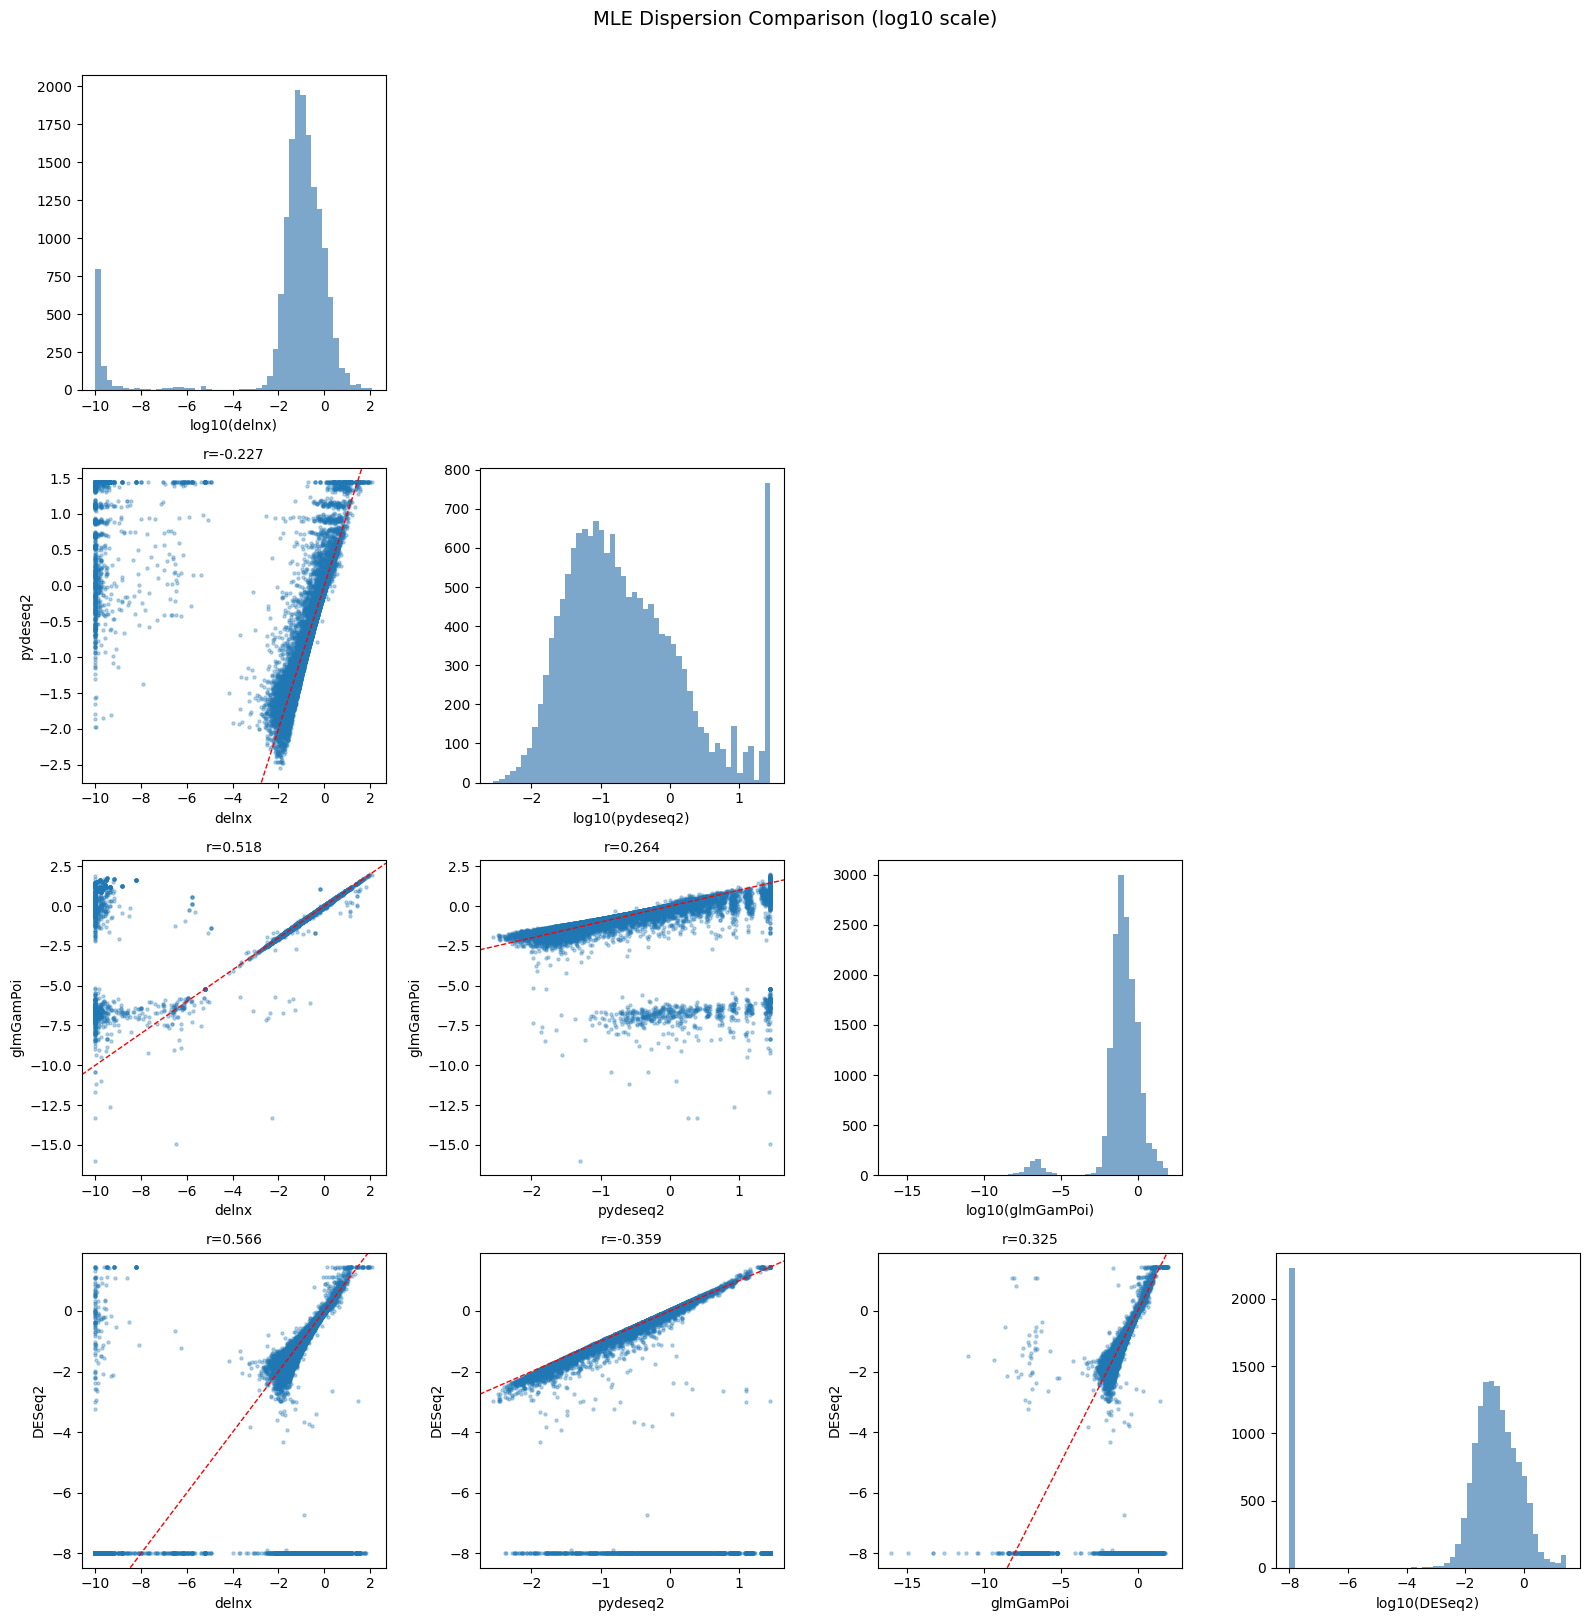

In [9]:
methods = ["delnx", "pydeseq2", "glmGamPoi", "DESeq2"]
n = len(methods)

fig, axes = plt.subplots(n, n, figsize=(16, 16))

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        ax = axes[i, j]
        if i == j:
            ax.hist(np.log10(disp_valid[m1]), bins=50, color="steelblue", alpha=0.7)
            ax.set_xlabel(f"log10({m1})")
        elif i > j:
            x, y = np.log10(disp_valid[m2]), np.log10(disp_valid[m1])
            ax.scatter(x, y, s=5, alpha=0.3)
            ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
            r, _ = pearsonr(x, y)
            ax.set_title(f"r={r:.3f}", fontsize=10)
            ax.set_xlabel(m2)
            ax.set_ylabel(m1)
        else:
            ax.axis("off")

fig.suptitle("MLE Dispersion Comparison (log10 scale)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.close()

## 4. Coefficient comparison (log2 fold change)

In [10]:
# Merge all results by gene name
lfc_df = pd.DataFrame({
    "delnx": res_dx.set_index("feature")["log2fc"],
    "pydeseq2": res_pydeseq.set_index("feature")["log2FoldChange"],
    "glmGamPoi": res_glmgp.set_index("feature")["log2fc"],
    "DESeq2": res_deseq2.set_index("feature")["log2fc"],
})
lfc_valid = lfc_df.dropna()
print(f"Genes with valid LFC in all methods: {len(lfc_valid)} / {len(lfc_df)}")

Genes with valid LFC in all methods: 16134 / 16199


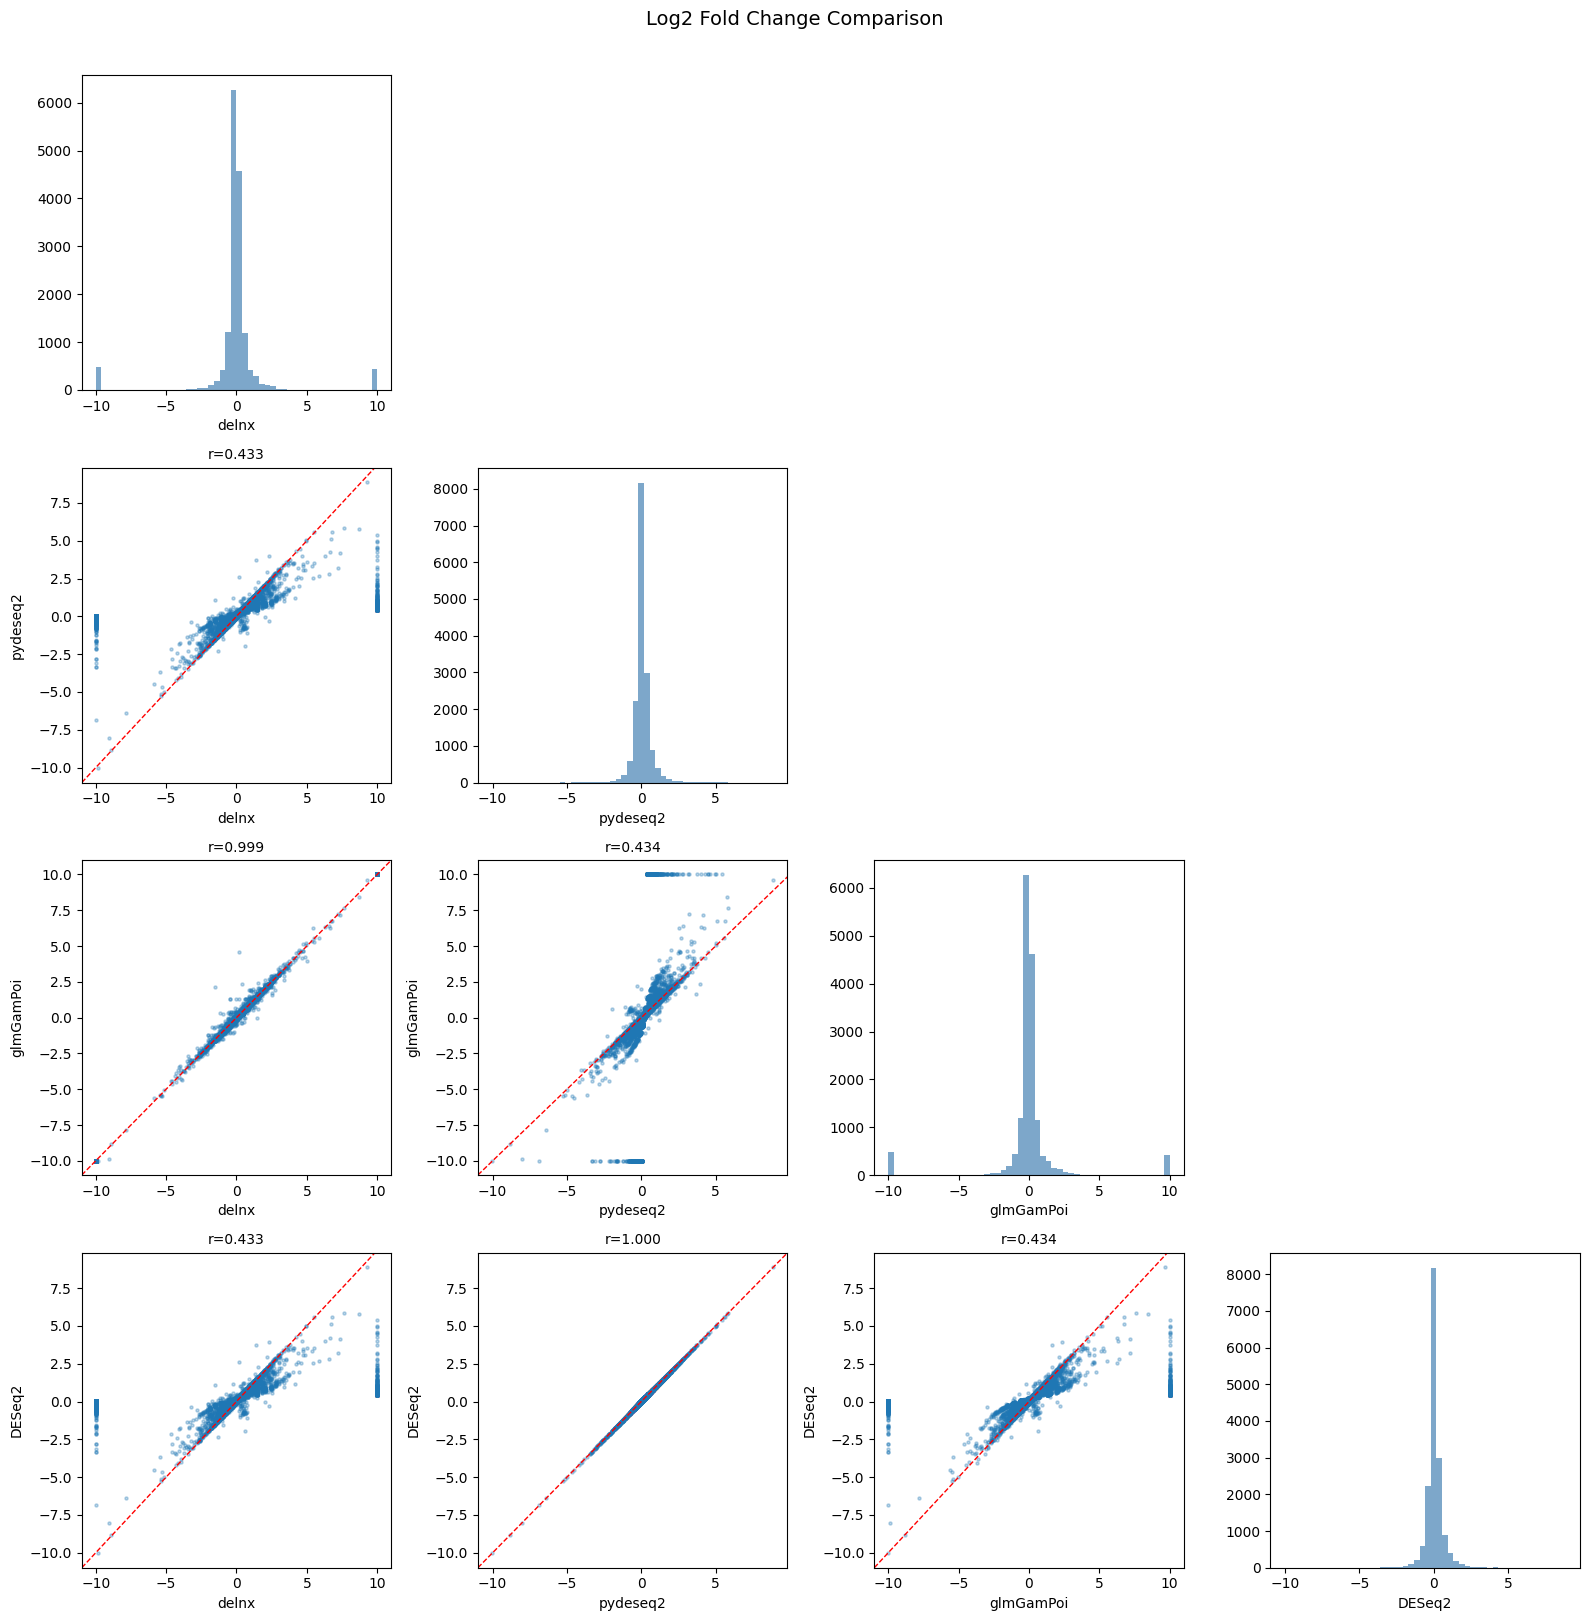

In [11]:
fig, axes = plt.subplots(n, n, figsize=(16, 16))

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        ax = axes[i, j]
        if i == j:
            ax.hist(lfc_valid[m1], bins=50, color="steelblue", alpha=0.7)
            ax.set_xlabel(m1)
        elif i > j:
            x, y = lfc_valid[m2], lfc_valid[m1]
            ax.scatter(x, y, s=5, alpha=0.3)
            ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
            r, _ = pearsonr(x, y)
            ax.set_title(f"r={r:.3f}", fontsize=10)
            ax.set_xlabel(m2)
            ax.set_ylabel(m1)
        else:
            ax.axis("off")

fig.suptitle("Log2 Fold Change Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.close()

## 5. P-value comparison

In [12]:
pval_df = pd.DataFrame({
    "delnx": res_dx.set_index("feature")["pval"],
    "pydeseq2": res_pydeseq.set_index("feature")["pvalue"],
    "glmGamPoi": res_glmgp.set_index("feature")["pval"],
    "DESeq2": res_deseq2.set_index("feature")["pval"],
})
pval_valid = pval_df.replace(0, np.nan).dropna()
nlog10_pval = -np.log10(pval_valid)
print(f"Genes with valid p-values in all methods: {len(pval_valid)} / {len(pval_df)}")

Genes with valid p-values in all methods: 16134 / 16199


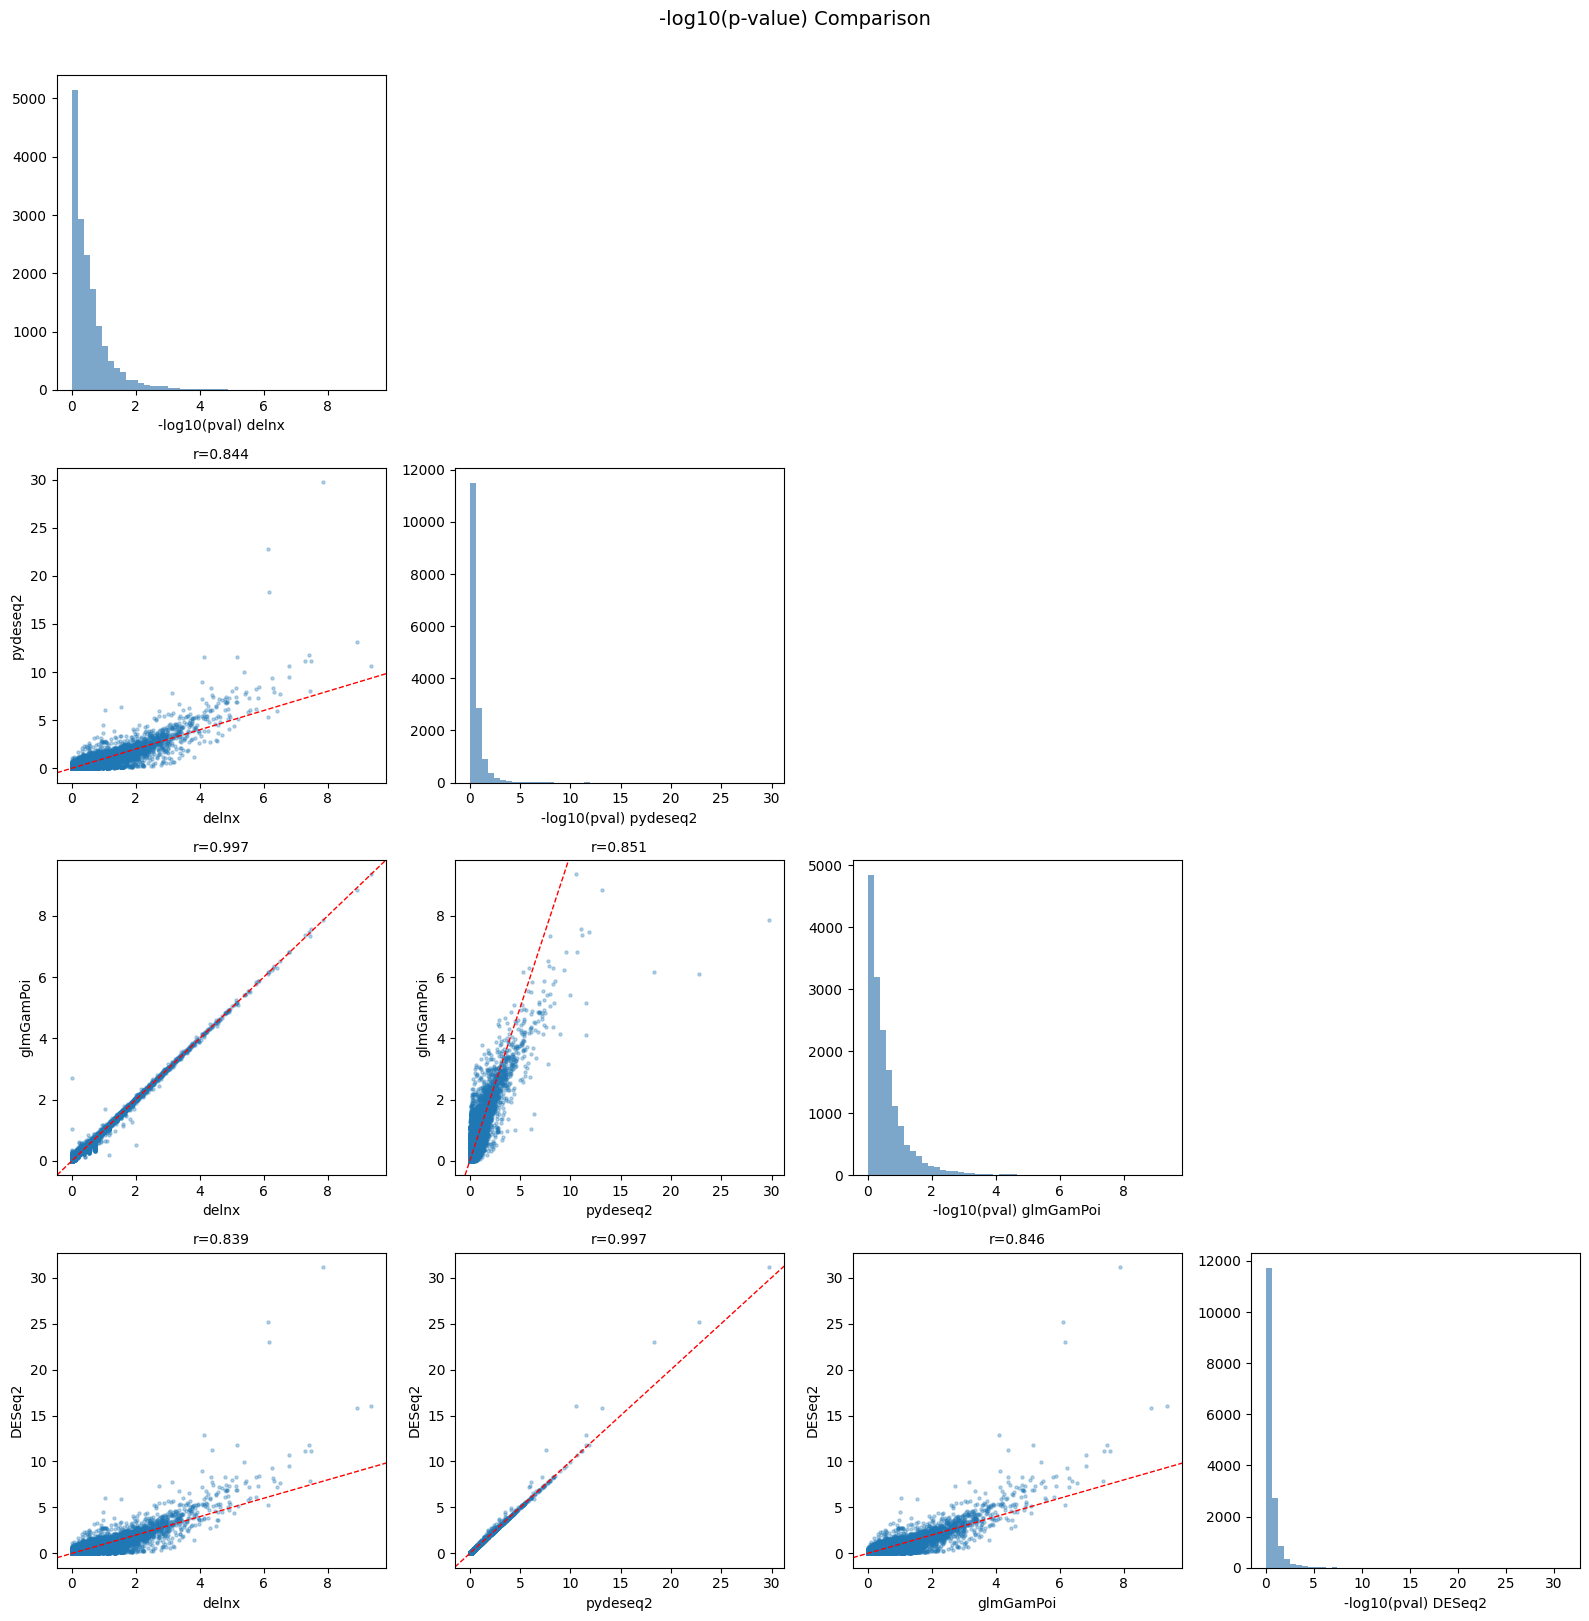

In [13]:
fig, axes = plt.subplots(n, n, figsize=(16, 16))

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        ax = axes[i, j]
        if i == j:
            ax.hist(nlog10_pval[m1], bins=50, color="steelblue", alpha=0.7)
            ax.set_xlabel(f"-log10(pval) {m1}")
        elif i > j:
            x, y = nlog10_pval[m2], nlog10_pval[m1]
            ax.scatter(x, y, s=5, alpha=0.3)
            ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
            r, _ = pearsonr(x, y)
            ax.set_title(f"r={r:.3f}", fontsize=10)
            ax.set_xlabel(m2)
            ax.set_ylabel(m1)
        else:
            ax.axis("off")

fig.suptitle("-log10(p-value) Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.close()

### Significance concordance

In [14]:
padj_df = pd.DataFrame({
    "delnx": res_dx.set_index("feature")["padj"],
    "pydeseq2": res_pydeseq.set_index("feature")["padj"],
    "glmGamPoi": res_glmgp.set_index("feature")["padj"],
    "DESeq2": res_deseq2.set_index("feature")["padj"],
}).dropna()

sig = padj_df < 0.05

print("Significant genes (padj < 0.05):")
for m in methods:
    print(f"  {m}: {sig[m].sum()}")

print("\nPairwise overlap (Jaccard index):")
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if j > i:
            s1, s2 = set(sig.index[sig[m1]]), set(sig.index[sig[m2]])
            jaccard = len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0
            print(f"  {m1} vs {m2}: {jaccard:.3f} ({len(s1 & s2)} shared / {len(s1 | s2)} union)")

Significant genes (padj < 0.05):
  delnx: 181
  pydeseq2: 316
  glmGamPoi: 187
  DESeq2: 326

Pairwise overlap (Jaccard index):
  delnx vs pydeseq2: 0.479 (161 shared / 336 union)
  delnx vs glmGamPoi: 0.968 (181 shared / 187 union)
  delnx vs DESeq2: 0.487 (166 shared / 341 union)
  pydeseq2 vs glmGamPoi: 0.488 (165 shared / 338 union)
  pydeseq2 vs DESeq2: 0.969 (316 shared / 326 union)
  glmGamPoi vs DESeq2: 0.496 (170 shared / 343 union)


## 6. Runtime comparison

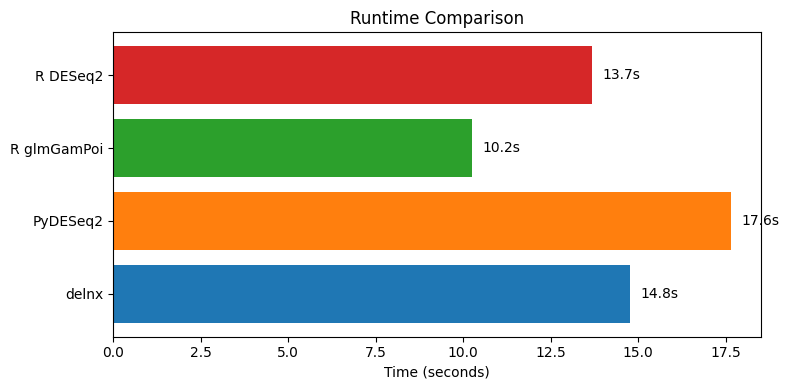

In [15]:
times = {"delnx": time_dx, "PyDESeq2": time_pydeseq, "R glmGamPoi": time_glmgp, "R DESeq2": time_deseq2}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(times.keys()), list(times.values()), color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Runtime Comparison")
for bar, t in zip(bars, times.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s", va="center")
plt.tight_layout()
plt.show()
plt.close()

## 7. Summary

In [16]:
# Build summary table
pairs = [
    ("delnx", "glmGamPoi"),
    ("delnx", "DESeq2"),
    ("delnx", "pydeseq2"),
    ("pydeseq2", "DESeq2"),
    ("glmGamPoi", "DESeq2"),
]

summary_rows = []
for m1, m2 in pairs:
    # Dispersion correlation
    d1, d2 = np.log10(disp_valid[m1]), np.log10(disp_valid[m2])
    r_disp, _ = pearsonr(d1, d2)

    # LFC correlation
    l1, l2 = lfc_valid[m1], lfc_valid[m2]
    r_lfc, _ = pearsonr(l1, l2)

    # P-value correlation
    p1, p2 = nlog10_pval[m1], nlog10_pval[m2]
    r_pval, _ = pearsonr(p1, p2)

    # Significance overlap
    s1, s2 = set(sig.index[sig[m1]]), set(sig.index[sig[m2]])
    jaccard = len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0

    summary_rows.append({
        "Comparison": f"{m1} vs {m2}",
        "Disp r (log10)": f"{r_disp:.3f}",
        "LFC r": f"{r_lfc:.3f}",
        "-log10(p) r": f"{r_pval:.3f}",
        "Sig. Jaccard": f"{jaccard:.3f}",
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

         Comparison Disp r (log10) LFC r -log10(p) r Sig. Jaccard
 delnx vs glmGamPoi          0.518 0.999       0.997        0.968
    delnx vs DESeq2          0.566 0.433       0.839        0.487
  delnx vs pydeseq2         -0.227 0.433       0.844        0.479
 pydeseq2 vs DESeq2         -0.359 1.000       0.997        0.969
glmGamPoi vs DESeq2          0.325 0.434       0.846        0.496


## 8. Simulation benchmark

We simulate pseudobulk count data from negative binomial distributions with known ground-truth
DE genes at different difficulty levels. For each scenario, we measure:

- **TPR** (true positive rate): fraction of true DE genes detected at padj < 0.05
- **FDR** (false discovery rate): fraction of called significant genes that are not truly DE

### Simulation parameters

| Scenario | Dispersion | Mean counts | DE log2FC | Sparsity | Samples per group |
|----------|-----------|-------------|-----------|----------|-------------------|
| Easy | 0.1 | 500 | 2.0 | 0% | 8 |
| Medium | 0.3 | 200 | 1.5 | 5% | 6 |
| Hard | 0.5 | 100 | 1.0 | 15% | 5 |
| Very hard | 1.0 | 50 | 0.5 | 30% | 4 |

In [17]:
def simulate_pseudobulk(
    n_genes=5000,
    n_de=500,
    n_samples_per_group=5,
    mean_counts=100,
    dispersion=0.5,
    de_log2fc=1.0,
    sparsity=0.0,
    seed=42,
):
    """Simulate pseudobulk NB counts with known DE genes."""
    rng = np.random.default_rng(seed)
    n_samples = 2 * n_samples_per_group

    # Gene mean expression (log-normal)
    gene_means = rng.lognormal(np.log(mean_counts), 1.0, size=n_genes)

    # Size factors (mild variation)
    size_factors = rng.lognormal(0, 0.2, size=n_samples)

    # Sample-level NB counts
    counts = np.zeros((n_samples, n_genes), dtype=int)
    for j in range(n_genes):
        for i in range(n_samples):
            mu = gene_means[j] * size_factors[i]
            r = 1.0 / max(dispersion, 1e-8)
            p = r / (r + mu)
            counts[i, j] = rng.negative_binomial(r, p)

    # DE genes: apply fold change in group B (samples n_per_group:)
    de_idx = rng.choice(n_genes, size=n_de, replace=False)
    de_directions = rng.choice([-1, 1], size=n_de)
    for k, gene in enumerate(de_idx):
        fc = 2 ** (de_log2fc * de_directions[k])
        for i in range(n_samples_per_group, n_samples):
            mu = gene_means[gene] * size_factors[i] * fc
            r = 1.0 / max(dispersion, 1e-8)
            p = r / (r + mu)
            counts[i, gene] = rng.negative_binomial(r, p)

    # Apply sparsity (zero inflation)
    if sparsity > 0:
        mask = rng.random(counts.shape) < sparsity
        counts[mask] = 0

    # Build AnnData
    import anndata as ad

    adata_sim = ad.AnnData(X=counts.astype(np.float64))
    adata_sim.var_names = [f"gene_{i}" for i in range(n_genes)]
    adata_sim.obs_names = [f"sample_{i}" for i in range(n_samples)]
    adata_sim.obs["condition"] = (
        ["A"] * n_samples_per_group + ["B"] * n_samples_per_group
    )

    truth = np.zeros(n_genes, dtype=bool)
    truth[de_idx] = True

    return adata_sim, truth


scenarios = {
    "Easy": dict(dispersion=0.1, mean_counts=500, de_log2fc=2.0, sparsity=0.0, n_samples_per_group=8),
    "Medium": dict(dispersion=0.3, mean_counts=200, de_log2fc=1.5, sparsity=0.05, n_samples_per_group=6),
    "Hard": dict(dispersion=0.5, mean_counts=100, de_log2fc=1.0, sparsity=0.15, n_samples_per_group=5),
    "Very hard": dict(dispersion=1.0, mean_counts=50, de_log2fc=0.5, sparsity=0.3, n_samples_per_group=4),
}

print("Scenarios defined:", list(scenarios.keys()))

Scenarios defined: ['Easy', 'Medium', 'Hard', 'Very hard']


In [18]:
def run_delnx(adata_sim):
    """Run delnx on simulated data."""
    fit = dx.tl.nb_fit(adata_sim, condition_key="condition", reference="A", verbose=False)
    res = dx.tl.nb_test(adata_sim, fit, contrast="condition[T.B]")
    return res.set_index("feature")["padj"]


def run_pydeseq(adata_sim):
    """Run PyDESeq2 on simulated data."""
    ad_copy = adata_sim.copy()
    ad_copy.X = np.round(ad_copy.X).astype(int)
    inference = DefaultInference()
    dds_sim = DeseqDataSet(adata=ad_copy, design="~ condition", inference=inference)
    dds_sim.deseq2()
    stat_sim = DeseqStats(dds_sim, contrast=["condition", "B", "A"], inference=inference)
    stat_sim.summary()
    return stat_sim.results_df["padj"]


def run_glmgampoi(adata_sim):
    """Run R glmGamPoi on simulated data."""
    c = np.round(np.asarray(adata_sim.X)).astype(int)
    ro.globalenv["sim_counts"] = c.T
    ro.globalenv["sim_condition"] = ro.FactorVector(
        adata_sim.obs["condition"].values,
        levels=ro.StrVector(["A", "B"]),
    )
    ro.globalenv["sim_genes"] = ro.StrVector(adata_sim.var_names.tolist())
    ro.globalenv["sim_samples"] = ro.StrVector(adata_sim.obs_names.tolist())
    ro.r('''
    rownames(sim_counts) <- sim_genes
    colnames(sim_counts) <- sim_samples
    sim_col <- data.frame(condition = sim_condition, row.names = sim_samples)
    sim_fit <- glm_gp(sim_counts, design = ~ condition, col_data = sim_col,
                      size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sim_res <- test_de(sim_fit, contrast = cond(condition = "B") - cond(condition = "A"))
    ''')
    padj = np.array(ro.r("sim_res$adj_pval"))
    names = np.array(ro.r("sim_res$name"))
    return pd.Series(padj, index=names)


def run_deseq2(adata_sim):
    """Run R DESeq2 on simulated data."""
    c = np.round(np.asarray(adata_sim.X)).astype(int)
    ro.globalenv["sim_counts"] = c.T
    ro.globalenv["sim_condition"] = ro.FactorVector(
        adata_sim.obs["condition"].values,
        levels=ro.StrVector(["A", "B"]),
    )
    ro.globalenv["sim_genes"] = ro.StrVector(adata_sim.var_names.tolist())
    ro.globalenv["sim_samples"] = ro.StrVector(adata_sim.obs_names.tolist())
    ro.r('''
    rownames(sim_counts) <- sim_genes
    colnames(sim_counts) <- sim_samples
    sim_col <- data.frame(condition = sim_condition, row.names = sim_samples)
    sim_dds <- DESeqDataSetFromMatrix(countData = sim_counts, colData = sim_col, design = ~ condition)
    sim_dds <- DESeq(sim_dds, quiet = TRUE)
    sim_res <- results(sim_dds, contrast = c("condition", "B", "A"))
    ''')
    padj = np.array(ro.r("sim_res$padj"))
    names = np.array(ro.r("rownames(sim_res)"))
    return pd.Series(padj, index=names)


def evaluate(padj, truth, gene_names, alpha=0.05):
    """Compute TPR, FDR, and null p-value calibration."""
    padj_arr = padj.reindex(gene_names).values
    called = padj_arr < alpha
    # Handle NaN as not significant
    called = np.where(np.isnan(called), False, called)

    tp = np.sum(called & truth)
    fp = np.sum(called & ~truth)
    fn = np.sum(~called & truth)

    tpr = tp / max(tp + fn, 1)
    fdr = fp / max(tp + fp, 1)

    return {"TPR": tpr, "FDR": fdr}


print("Runner functions defined")

Runner functions defined


In [19]:
sim_results = []
runners = {
    "delnx": run_delnx,
    "PyDESeq2": run_pydeseq,
    "glmGamPoi": run_glmgampoi,
    "DESeq2": run_deseq2,
}

for scenario_name, params in scenarios.items():
    print(f"\n{'='*60}")
    print(f"Scenario: {scenario_name}")
    print(f"{'='*60}")

    adata_sim, truth = simulate_pseudobulk(**params)
    gene_names = adata_sim.var_names

    for method_name, runner in runners.items():
        try:
            padj = runner(adata_sim)
            metrics = evaluate(padj, truth, gene_names)
            metrics["method"] = method_name
            metrics["scenario"] = scenario_name
            sim_results.append(metrics)
            print(f"  {method_name:12s}: TPR={metrics['TPR']:.3f}, FDR={metrics['FDR']:.3f}")
        except Exception as e:
            print(f"  {method_name:12s}: FAILED — {e}")
            sim_results.append({"method": method_name, "scenario": scenario_name, "TPR": np.nan, "FDR": np.nan})

sim_df = pd.DataFrame(sim_results)
print("\n\nAll simulation results:")
print(sim_df.pivot_table(index="scenario", columns="method", values=["TPR", "FDR"]).to_string())


Scenario: Easy


  delnx       : TPR=1.000, FDR=0.266
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 0.50 seconds.

Fitting dispersion trend curve...
... done in 0.09 seconds.

Fitting MAP dispersions...


...

... done in 0.87 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


... done in 0.62 seconds.



Log2 fold change & Wald test p-value: condition B vs A
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0     40.813375       -1.291916  1.918741 -0.673314  0.500747  0.999973
gene_1      2.446001        4.856774  3.289512  1.476442  0.139825       NaN
gene_2     79.838854       -0.912391  2.048218 -0.445456  0.655990  0.999973
gene_3     64.814061        0.716964  1.780502  0.402675  0.687187  0.999973
gene_4      6.388776        0.229695  1.913277  0.120053  0.904441       NaN
...              ...             ...       ...       ...       ...       ...
gene_4995  51.509391       -1.640959  2.234458 -0.734388  0.462712  0.999973
gene_4996   3.310477        5.302006  3.008067  1.762596  0.077969       NaN
gene_4997  28.734798        1.941724  2.158348  0.899634  0.368315       NaN
gene_4998  18.287961       -0.702736  2.388097 -0.294266  0.768554       NaN
gene_4999  10.551228       -0.655921  2.095376 -0.313033  0.754256       NaN

[5000 rows x 6 colum

  glmGamPoi   : TPR=0.000, FDR=0.000


  DESeq2      : TPR=0.012, FDR=0.800


All simulation results:
                FDR                                  TPR                         
method       DESeq2  PyDESeq2     delnx glmGamPoi DESeq2 PyDESeq2 delnx glmGamPoi
scenario                                                                         
Easy       0.082569  0.082569  0.265786  0.266862  1.000    1.000   1.0       1.0
Hard       1.000000  1.000000  1.000000  1.000000  0.000    0.000   0.0       0.0
Medium     0.061069  0.034483  0.000000  0.000000  0.246    0.224   0.0       0.0
Very hard  0.800000  0.761905  0.000000  0.000000  0.012    0.010   0.0       0.0


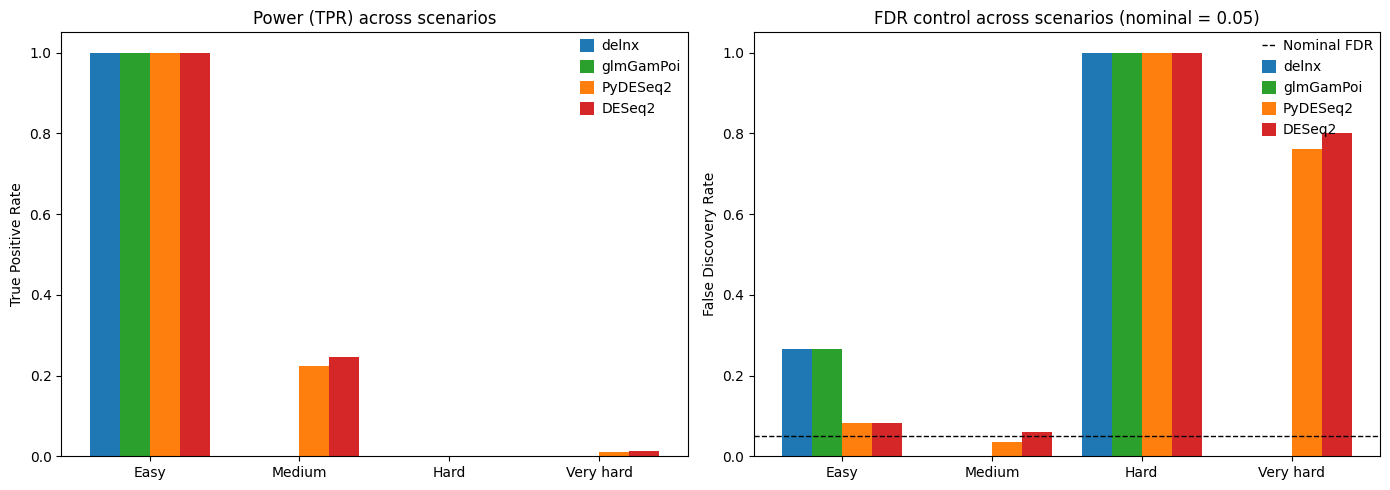

In [20]:
scenario_order = ["Easy", "Medium", "Hard", "Very hard"]
method_order = ["delnx", "glmGamPoi", "PyDESeq2", "DESeq2"]
colors = {"delnx": "#1f77b4", "glmGamPoi": "#2ca02c", "PyDESeq2": "#ff7f0e", "DESeq2": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TPR
ax = axes[0]
x = np.arange(len(scenario_order))
width = 0.2
for i, method in enumerate(method_order):
    vals = [sim_df[(sim_df["scenario"] == s) & (sim_df["method"] == method)]["TPR"].values[0]
            for s in scenario_order]
    ax.bar(x + i * width, vals, width, label=method, color=colors[method])
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(scenario_order)
ax.set_ylabel("True Positive Rate")
ax.set_title("Power (TPR) across scenarios")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")

# FDR
ax = axes[1]
for i, method in enumerate(method_order):
    vals = [sim_df[(sim_df["scenario"] == s) & (sim_df["method"] == method)]["FDR"].values[0]
            for s in scenario_order]
    ax.bar(x + i * width, vals, width, label=method, color=colors[method])
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(scenario_order)
ax.set_ylabel("False Discovery Rate")
ax.set_title("FDR control across scenarios (nominal = 0.05)")
ax.axhline(0.05, color="black", linestyle="--", linewidth=1, label="Nominal FDR")
ax.set_ylim(0, max(0.15, ax.get_ylim()[1]))
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()
plt.close()

## 9. Scalability benchmark

We measure wall-clock time for each method at different dataset sizes. For delnx, we report
both the **cold** time (including JAX JIT compilation) and the **warm** time (JIT cache populated).
All other methods have no JIT overhead.

In [21]:
import jax
# Clear JAX compilation cache for cold-start measurement
jax.clear_caches()

gene_sizes = [1000, 5000, 10000, 20000]
n_samples_speed = 10  # 5+5

speed_results = []

for n_genes in gene_sizes:
    print(f"\n--- {n_genes} genes, {n_samples_speed} samples ---")
    adata_speed, _ = simulate_pseudobulk(
        n_genes=n_genes, n_de=0, n_samples_per_group=n_samples_speed // 2,
        mean_counts=100, dispersion=0.5, seed=123,
    )

    # delnx cold (first run after cache clear)
    if n_genes == gene_sizes[0]:
        jax.clear_caches()
    t0 = time.time()
    fit_speed = dx.tl.nb_fit(adata_speed, condition_key="condition", reference="A", verbose=False)
    _ = dx.tl.nb_test(adata_speed, fit_speed, contrast="condition[T.B]")
    t_cold = time.time() - t0
    # delnx warm (JIT cached)
    t0 = time.time()
    fit_speed = dx.tl.nb_fit(adata_speed, condition_key="condition", reference="A", verbose=False)
    _ = dx.tl.nb_test(adata_speed, fit_speed, contrast="condition[T.B]")
    t_warm = time.time() - t0
    speed_results.append({"n_genes": n_genes, "method": "delnx (cold)", "time": t_cold})
    speed_results.append({"n_genes": n_genes, "method": "delnx (warm)", "time": t_warm})
    print(f"  delnx cold: {t_cold:.1f}s, warm: {t_warm:.1f}s")

    # PyDESeq2
    ad_sp = adata_speed.copy()
    ad_sp.X = np.round(ad_sp.X).astype(int)
    t0 = time.time()
    inf_sp = DefaultInference()
    dds_sp = DeseqDataSet(adata=ad_sp, design="~ condition", inference=inf_sp)
    dds_sp.deseq2()
    stat_sp = DeseqStats(dds_sp, contrast=["condition", "B", "A"], inference=inf_sp)
    stat_sp.summary()
    t_pydeseq = time.time() - t0
    speed_results.append({"n_genes": n_genes, "method": "PyDESeq2", "time": t_pydeseq})
    print(f"  PyDESeq2:   {t_pydeseq:.1f}s")

    # R glmGamPoi
    c_sp = np.round(np.asarray(adata_speed.X)).astype(int)
    ro.globalenv["sp_counts"] = c_sp.T
    ro.globalenv["sp_cond"] = ro.FactorVector(
        adata_speed.obs["condition"].values, levels=ro.StrVector(["A", "B"]))
    ro.globalenv["sp_genes"] = ro.StrVector(adata_speed.var_names.tolist())
    ro.globalenv["sp_samples"] = ro.StrVector(adata_speed.obs_names.tolist())
    t0 = time.time()
    ro.r('''
    rownames(sp_counts) <- sp_genes; colnames(sp_counts) <- sp_samples
    sp_col <- data.frame(condition = sp_cond, row.names = sp_samples)
    sp_fit <- glm_gp(sp_counts, design = ~ condition, col_data = sp_col,
                     size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sp_res <- test_de(sp_fit, contrast = cond(condition = "B") - cond(condition = "A"))
    ''')
    t_gp = time.time() - t0
    speed_results.append({"n_genes": n_genes, "method": "glmGamPoi", "time": t_gp})
    print(f"  glmGamPoi:  {t_gp:.1f}s")

    # R DESeq2
    t0 = time.time()
    ro.r('''
    sp_dds <- DESeqDataSetFromMatrix(countData = sp_counts, colData = sp_col, design = ~ condition)
    sp_dds <- DESeq(sp_dds, quiet = TRUE)
    sp_res2 <- results(sp_dds, contrast = c("condition", "B", "A"))
    ''')
    t_d2 = time.time() - t0
    speed_results.append({"n_genes": n_genes, "method": "DESeq2", "time": t_d2})
    print(f"  DESeq2:     {t_d2:.1f}s")

speed_df = pd.DataFrame(speed_results)
print("\n\nSpeed results:")
print(speed_df.pivot_table(index="n_genes", columns="method", values="time").to_string())


--- 1000 genes, 10 samples ---


  delnx cold: 7.0s, warm: 0.0s
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 0.27 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...


...

... done in 1.02 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


... done in 1.12 seconds.



Log2 fold change & Wald test p-value: condition B vs A
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0       29.923594       -0.163720  0.623973 -0.262384  0.793026  0.993347
gene_1       40.380436        0.364627  0.626820  0.581710  0.560762  0.987736
gene_2      271.407336       -0.441768  0.665392 -0.663921  0.506741  0.982564
gene_3       66.760640       -0.817599  0.694287 -1.177610  0.238952  0.935904
gene_4      299.300307       -0.372317  0.684603 -0.543843  0.586549  0.988600
...                ...             ...       ...       ...       ...       ...
gene_19995   45.015567        0.014593  0.545650  0.026744  0.978664  0.999848
gene_19996   35.796350       -0.313322  0.638305 -0.490866  0.623521  0.991431
gene_19997   42.409066       -1.174771  0.730168 -1.608905  0.107637  0.860084
gene_19998  139.199123       -0.281212  0.734117 -0.383061  0.701674  0.993347
gene_19999   48.389596       -0.351533  0.650340 -0.540538  0.588826  0.9886

  glmGamPoi:  11.3s


  DESeq2:     7.1s


Speed results:
method     DESeq2  PyDESeq2  delnx (cold)  delnx (warm)  glmGamPoi
n_genes                                                           
1000     1.150677  1.533939      6.981722      0.030133   0.485077
5000     2.037874  2.475996      3.420921      0.171981   2.818218
10000    3.223071  3.689054      4.765796      0.535188   4.541535
20000    7.121293  5.799826      6.328422      1.923073  11.268031


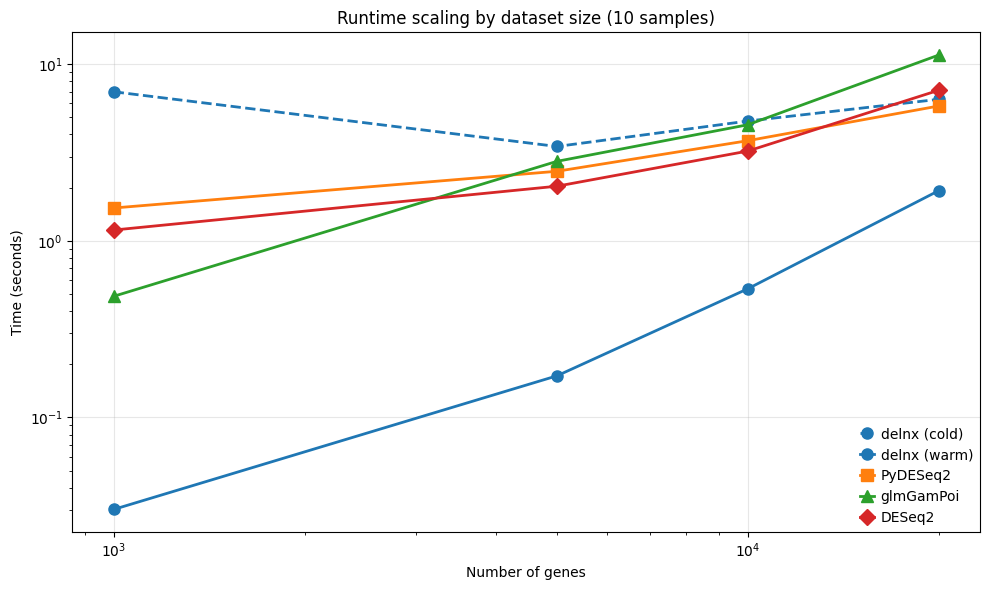

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

method_styles = {
    "delnx (cold)": dict(color="#1f77b4", linestyle="--", marker="o"),
    "delnx (warm)": dict(color="#1f77b4", linestyle="-", marker="o"),
    "PyDESeq2": dict(color="#ff7f0e", linestyle="-", marker="s"),
    "glmGamPoi": dict(color="#2ca02c", linestyle="-", marker="^"),
    "DESeq2": dict(color="#d62728", linestyle="-", marker="D"),
}

for method, style in method_styles.items():
    subset = speed_df[speed_df["method"] == method].sort_values("n_genes")
    ax.plot(subset["n_genes"], subset["time"], label=method, linewidth=2, markersize=8, **style)

ax.set_xlabel("Number of genes")
ax.set_ylabel("Time (seconds)")
ax.set_title("Runtime scaling by dataset size (10 samples)")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### 9.1 Scaling with samples (pseudobulk perturbation screen)

For perturbation screens, the number of samples (conditions × replicates) grows large.
We fix genes at 20,000 and vary sample count from 10 to 200.

In [23]:
def simulate_perturbation_screen(n_genes, n_conditions, n_replicates, mean_counts=100, dispersion=0.5, seed=42):
    """Simulate a perturbation screen with multiple conditions vs a shared control."""
    import anndata as ad

    rng = np.random.default_rng(seed)
    n_samples = n_replicates + n_conditions * n_replicates  # control + perturbations

    gene_means = rng.lognormal(np.log(mean_counts), 1.0, size=n_genes)
    size_factors = rng.lognormal(0, 0.2, size=n_samples)

    counts = np.zeros((n_samples, n_genes), dtype=int)
    for j in range(n_genes):
        r = 1.0 / max(dispersion, 1e-8)
        for i in range(n_samples):
            mu = gene_means[j] * size_factors[i]
            p = r / (r + mu)
            counts[i, j] = rng.negative_binomial(r, p)

    # Labels: control replicates first, then condition replicates
    labels = ["control"] * n_replicates
    for c in range(n_conditions):
        labels += [f"cond_{c}"] * n_replicates

    adata_sim = ad.AnnData(X=counts.astype(np.float64))
    adata_sim.var_names = [f"gene_{i}" for i in range(n_genes)]
    adata_sim.obs_names = [f"sample_{i}" for i in range(n_samples)]
    adata_sim.obs["condition"] = labels
    return adata_sim


# Scaling with samples: fix genes=20k, vary conditions
n_genes_fixed = 20000
sample_configs = [
    {"n_conditions": 1, "n_replicates": 5, "label": "10 (1×5+5)"},
    {"n_conditions": 5, "n_replicates": 3, "label": "18 (5×3+3)"},
    {"n_conditions": 10, "n_replicates": 3, "label": "33 (10×3+3)"},
    {"n_conditions": 20, "n_replicates": 3, "label": "63 (20×3+3)"},
    {"n_conditions": 50, "n_replicates": 3, "label": "153 (50×3+3)"},
]

sample_speed = []

for cfg in sample_configs:
    n_cond, n_rep, label = cfg["n_conditions"], cfg["n_replicates"], cfg["label"]
    n_total = n_rep + n_cond * n_rep
    print(f"\n--- {n_genes_fixed} genes, {label} samples ({n_cond} conditions) ---")

    adata_sp = simulate_perturbation_screen(n_genes_fixed, n_cond, n_rep)

    # delnx (warm — JIT already cached from section 9)
    t0 = time.time()
    fit_sp = dx.tl.nb_fit(adata_sp, condition_key="condition", reference="control", verbose=False)
    _ = dx.tl.nb_test(adata_sp, fit_sp, contrast=fit_sp.design_column_names[1])
    t_dx = time.time() - t0
    sample_speed.append({"n_samples": n_total, "label": label, "method": "delnx", "time": t_dx})
    print(f"  delnx:      {t_dx:.1f}s ({fit_sp.design_matrix.shape[1]} coefficients)")

    # PyDESeq2
    ad_sp = adata_sp.copy()
    ad_sp.X = np.round(ad_sp.X).astype(int)
    t0 = time.time()
    inf_sp = DefaultInference()
    dds_sp = DeseqDataSet(adata=ad_sp, design="~ condition", inference=inf_sp)
    dds_sp.deseq2()
    stat_sp = DeseqStats(dds_sp, contrast=["condition", "cond_0", "control"], inference=inf_sp)
    stat_sp.summary()
    t_py = time.time() - t0
    sample_speed.append({"n_samples": n_total, "label": label, "method": "PyDESeq2", "time": t_py})
    print(f"  PyDESeq2:   {t_py:.1f}s")

    # R glmGamPoi
    c_sp = np.round(np.asarray(adata_sp.X)).astype(int)
    ro.globalenv["sp_counts"] = c_sp.T
    ro.globalenv["sp_cond"] = ro.FactorVector(
        adata_sp.obs["condition"].values,
        levels=ro.StrVector(["control"] + [f"cond_{i}" for i in range(n_cond)]))
    ro.globalenv["sp_genes"] = ro.StrVector(adata_sp.var_names.tolist())
    ro.globalenv["sp_samples"] = ro.StrVector(adata_sp.obs_names.tolist())
    t0 = time.time()
    ro.r('''
    rownames(sp_counts) <- sp_genes; colnames(sp_counts) <- sp_samples
    sp_col <- data.frame(condition = sp_cond, row.names = sp_samples)
    sp_fit <- glm_gp(sp_counts, design = ~ condition, col_data = sp_col,
                     size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sp_res <- test_de(sp_fit, contrast = cond(condition = "cond_0") - cond(condition = "control"))
    ''')
    t_gp = time.time() - t0
    sample_speed.append({"n_samples": n_total, "label": label, "method": "glmGamPoi", "time": t_gp})
    print(f"  glmGamPoi:  {t_gp:.1f}s")

    # R DESeq2
    t0 = time.time()
    ro.r('''
    sp_dds <- DESeqDataSetFromMatrix(countData = sp_counts, colData = sp_col, design = ~ condition)
    sp_dds <- DESeq(sp_dds, quiet = TRUE)
    sp_res2 <- results(sp_dds, contrast = c("condition", "cond_0", "control"))
    ''')
    t_d2 = time.time() - t0
    sample_speed.append({"n_samples": n_total, "label": label, "method": "DESeq2", "time": t_d2})
    print(f"  DESeq2:     {t_d2:.1f}s")

sample_speed_df = pd.DataFrame(sample_speed)
print("\n\nSample scaling results:")
print(sample_speed_df.pivot_table(index="label", columns="method", values="time").to_string())


--- 20000 genes, 10 (1×5+5) samples (1 conditions) ---


  delnx:      1.9s (2 coefficients)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.04 seconds.

Fitting dispersion trend curve...


...

... done in 0.20 seconds.

Replacing 0 outlier genes.

Running Wald tests...


... done in 1.35 seconds.



Log2 fold change & Wald test p-value: condition cond_0 vs control
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0      127.129013       -0.060903  0.807015 -0.075467  0.939843  0.999079
gene_1       36.594508       -0.019173  0.922087 -0.020793  0.983411  0.999137
gene_2      201.358077        1.541951  0.790163  1.951433  0.051006  0.781865
gene_3      244.165734        0.239506  0.872774  0.274419  0.783762  0.995877
gene_4       12.688108       -1.637741  0.950171 -1.723627  0.084775  0.833591
...                ...             ...       ...       ...       ...       ...
gene_19995  584.929924        1.289045  0.828498  1.555882  0.119736  0.867397
gene_19996   36.151614        0.150412  0.828638  0.181517  0.855962  0.997384
gene_19997  173.915301        0.447913  0.812096  0.551552  0.581255  0.985819
gene_19998  159.779653       -0.220777  0.789915 -0.279495  0.779865  0.995137
gene_19999  293.515213        1.225824  0.890785  1.376117  0.168

  glmGamPoi:  52.6s


  DESeq2:     197.9s


Sample scaling results:
method            DESeq2  PyDESeq2      delnx  glmGamPoi
label                                                   
10 (1×5+5)      7.032179  6.041413   1.945414  12.949594
153 (50×3+3)  197.863783  7.875741  21.519315  52.618387
18 (5×3+3)     11.388280  6.050944  11.135837  15.249070
33 (10×3+3)    22.089407  6.182658  11.848979  14.323368
63 (20×3+3)    47.302961  7.231252  12.551563  22.266582


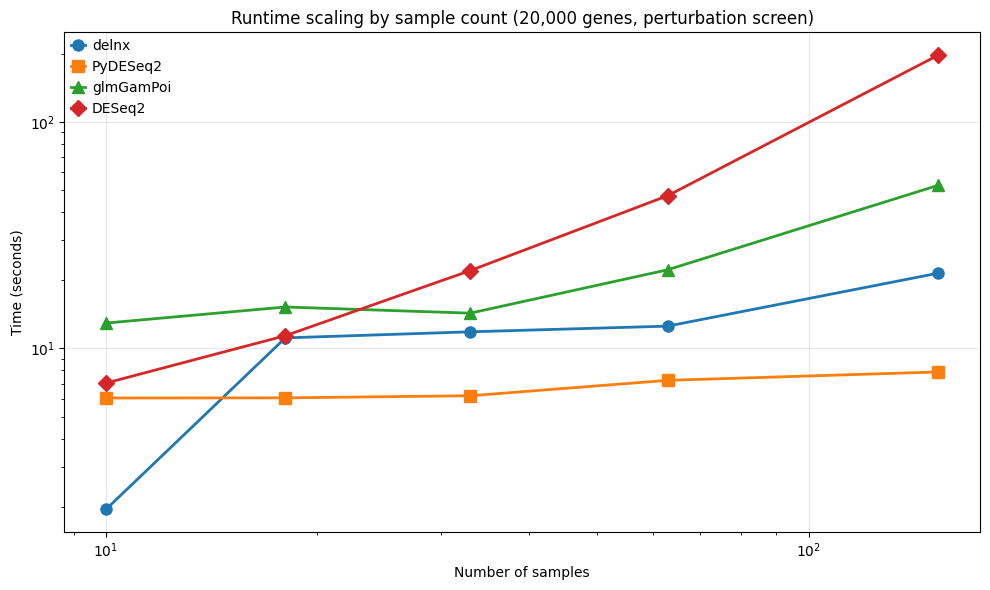

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for method, style in [
    ("delnx", dict(color="#1f77b4", marker="o")),
    ("PyDESeq2", dict(color="#ff7f0e", marker="s")),
    ("glmGamPoi", dict(color="#2ca02c", marker="^")),
    ("DESeq2", dict(color="#d62728", marker="D")),
]:
    subset = sample_speed_df[sample_speed_df["method"] == method].sort_values("n_samples")
    ax.plot(subset["n_samples"], subset["time"], label=method, linewidth=2, markersize=8, **style)

ax.set_xlabel("Number of samples")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Runtime scaling by sample count ({n_genes_fixed:,} genes, perturbation screen)")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### 9.2 Single-cell-like datasets

Single-cell pseudobulk datasets differ from bulk RNA-seq in several ways:
- **Higher sparsity** — many genes have zero counts
- **Lower mean counts** — especially after aggregation with few cells per pseudobulk
- **More genes** — typically 20-30k genes tested
- **Variable replicate counts** — some conditions have few pseudobulk samples

We simulate datasets with characteristics matching typical scRNA-seq pseudobulk analyses
at different scales.

In [25]:
sc_configs = {
    "Small (5k genes, 10 samples)": dict(
        n_genes=5000, n_samples_per_group=5, mean_counts=30,
        dispersion=1.0, sparsity=0.3, de_log2fc=1.0,
    ),
    "Medium (15k genes, 20 samples)": dict(
        n_genes=15000, n_samples_per_group=10, mean_counts=50,
        dispersion=0.8, sparsity=0.25, de_log2fc=1.0,
    ),
    "Large (25k genes, 40 samples)": dict(
        n_genes=25000, n_samples_per_group=20, mean_counts=50,
        dispersion=0.8, sparsity=0.25, de_log2fc=1.0,
    ),
    "Very large (30k genes, 100 samples)": dict(
        n_genes=30000, n_samples_per_group=50, mean_counts=80,
        dispersion=0.5, sparsity=0.2, de_log2fc=1.0,
    ),
}

sc_speed = []

for name, params in sc_configs.items():
    n_g = params["n_genes"]
    n_s = 2 * params["n_samples_per_group"]
    print(f"\n--- {name} ---")

    adata_sc, _ = simulate_pseudobulk(**params, n_de=int(n_g * 0.1))

    # delnx
    t0 = time.time()
    fit_sc = dx.tl.nb_fit(adata_sc, condition_key="condition", reference="A", verbose=False)
    _ = dx.tl.nb_test(adata_sc, fit_sc, contrast="condition[T.B]")
    t_dx = time.time() - t0
    sc_speed.append({"config": name, "n_genes": n_g, "n_samples": n_s, "method": "delnx", "time": t_dx})
    print(f"  delnx:      {t_dx:.1f}s")

    # PyDESeq2
    ad_sc = adata_sc.copy()
    ad_sc.X = np.round(ad_sc.X).astype(int)
    t0 = time.time()
    inf_sc = DefaultInference()
    dds_sc = DeseqDataSet(adata=ad_sc, design="~ condition", inference=inf_sc)
    dds_sc.deseq2()
    stat_sc = DeseqStats(dds_sc, contrast=["condition", "B", "A"], inference=inf_sc)
    stat_sc.summary()
    t_py = time.time() - t0
    sc_speed.append({"config": name, "n_genes": n_g, "n_samples": n_s, "method": "PyDESeq2", "time": t_py})
    print(f"  PyDESeq2:   {t_py:.1f}s")

    # R glmGamPoi
    c_sc = np.round(np.asarray(adata_sc.X)).astype(int)
    ro.globalenv["sc_counts"] = c_sc.T
    ro.globalenv["sc_cond"] = ro.FactorVector(
        adata_sc.obs["condition"].values, levels=ro.StrVector(["A", "B"]))
    ro.globalenv["sc_genes"] = ro.StrVector(adata_sc.var_names.tolist())
    ro.globalenv["sc_samples"] = ro.StrVector(adata_sc.obs_names.tolist())
    t0 = time.time()
    ro.r('''
    rownames(sc_counts) <- sc_genes; colnames(sc_counts) <- sc_samples
    sc_col <- data.frame(condition = sc_cond, row.names = sc_samples)
    sc_fit <- glm_gp(sc_counts, design = ~ condition, col_data = sc_col,
                     size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sc_res <- test_de(sc_fit, contrast = cond(condition = "B") - cond(condition = "A"))
    ''')
    t_gp = time.time() - t0
    sc_speed.append({"config": name, "n_genes": n_g, "n_samples": n_s, "method": "glmGamPoi", "time": t_gp})
    print(f"  glmGamPoi:  {t_gp:.1f}s")

    # R DESeq2 (use poscounts for sparse data)
    t0 = time.time()
    try:
        ro.r('''
        sc_dds <- DESeqDataSetFromMatrix(countData = sc_counts, colData = sc_col, design = ~ condition)
        sc_dds <- DESeq(sc_dds, quiet = TRUE, sfType = "poscounts")
        sc_res2 <- results(sc_dds, contrast = c("condition", "B", "A"))
        ''')
        t_d2 = time.time() - t0
        print(f"  DESeq2:     {t_d2:.1f}s")
    except Exception as e:
        t_d2 = time.time() - t0
        print(f"  DESeq2:     {t_d2:.1f}s (failed: {type(e).__name__})")
    sc_speed.append({"config": name, "n_genes": n_g, "n_samples": n_s, "method": "DESeq2", "time": t_d2})

sc_speed_df = pd.DataFrame(sc_speed)
print("\n\nSingle-cell pseudobulk speed results:")
print(sc_speed_df.pivot_table(index="config", columns="method", values="time").to_string())


--- Small (5k genes, 10 samples) ---


  delnx:      0.3s
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 0.53 seconds.

Fitting dispersion trend curve...
... done in 0.08 seconds.

Fitting MAP dispersions...


...

... done in 2.30 seconds.



Log2 fold change & Wald test p-value: condition B vs A
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0       91.796447       -0.052137  0.457173 -0.114043  0.909204  0.999991
gene_1       21.473706       -0.086090  0.405845 -0.212124  0.832010  0.999991
gene_2      158.737155       -0.244109  0.490930 -0.497238  0.619021  0.999991
gene_3      167.845073       -0.186470  0.385934 -0.483164  0.628979  0.999991
gene_4       10.406036       -0.288521  0.363576 -0.793564  0.427449  0.999991
...                ...             ...       ...       ...       ...       ...
gene_29995   88.766674        0.220972  0.421301  0.524499  0.599932  0.999991
gene_29996   77.651288       -0.158180  0.414750 -0.381387  0.702916  0.999991
gene_29997  343.111429       -0.014211  0.482778 -0.029436  0.976517  0.999991
gene_29998  101.298973        0.532490  0.438245  1.215050  0.224347  0.999991
gene_29999   30.765726        0.221938  0.363838  0.609990  0.541868  0.9999

  glmGamPoi:  28.5s


R callback write-console: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.
  


  DESeq2:     38.4s


Single-cell pseudobulk speed results:
method                                  DESeq2     PyDESeq2      delnx  glmGamPoi
config                                                                           
Large (25k genes, 40 samples)        18.531133   179.066631  12.478956  17.916682
Medium (15k genes, 20 samples)       10.022376     5.794628   8.886368   8.958513
Small (5k genes, 10 samples)          4.853226     2.964952   0.345145   2.820562
Very large (30k genes, 100 samples)  38.449234  1369.918043  14.456906  28.474000


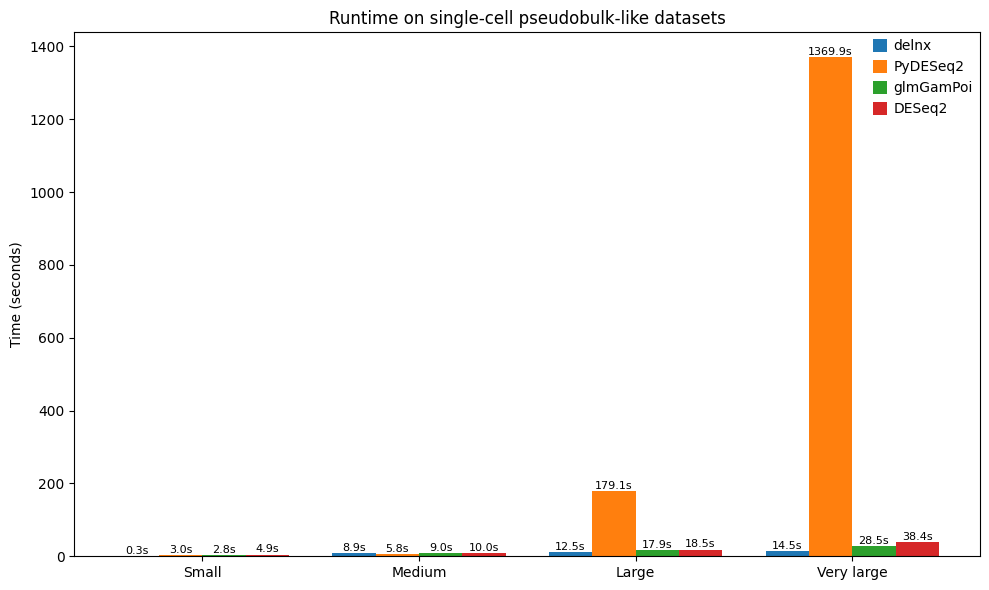

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

config_labels = list(sc_configs.keys())
x = np.arange(len(config_labels))
width = 0.2

for i, (method, color) in enumerate([
    ("delnx", "#1f77b4"), ("PyDESeq2", "#ff7f0e"),
    ("glmGamPoi", "#2ca02c"), ("DESeq2", "#d62728"),
]):
    vals = [sc_speed_df[(sc_speed_df["config"] == c) & (sc_speed_df["method"] == method)]["time"].values[0]
            for c in config_labels]
    bars = ax.bar(x + i * width, vals, width, label=method, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{v:.1f}s", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([c.split("(")[0].strip() for c in config_labels])
ax.set_ylabel("Time (seconds)")
ax.set_title("Runtime on single-cell pseudobulk-like datasets")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()